In [1]:
# pip install scikit-image
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread,imshow
from skimage.color import rgb2hsv,rgb2gray
from skimage.filters import threshold_otsu
import cv2

### Process of binary thresholding
1. Convert the RGB/BGR to grayscale
2. Find a optimum threshold value - random(trail and error or histogram) or threshold_otsu
3. switch on / off the pixels based on threshold

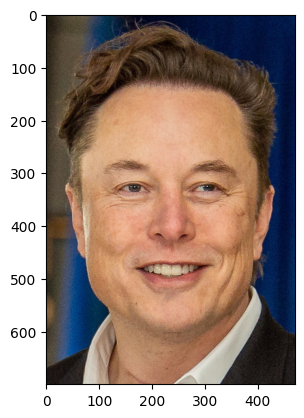

In [50]:
# image = cv2.imread('sunflower.jpg') # CV2 reads as BGR
image = imread('elon.jpg') # skimage imread reads as RGB
# image = plt.imread('sunflower.jpg') # matplotlib reads as RGB
plt.imshow(image)

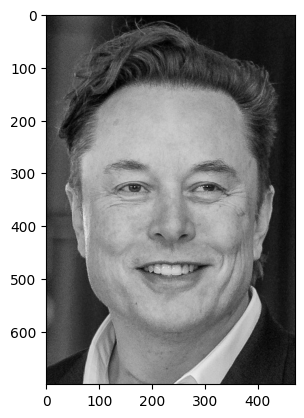

In [51]:
# image_grayscale = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY) # in the range of 0-255
image_grayscale = rgb2gray(image) # in the range of 0-1
plt.imshow(image_grayscale,cmap='gray')

In [52]:
image_grayscale.ndim

2

In [53]:
image_grayscale.shape

(700, 471)

In [54]:
image_grayscale

array([[0.15062667, 0.16182588, 0.17359059, ..., 0.09106039, 0.11180706,
        0.11854902],
       [0.17415608, 0.15006118, 0.1343749 , ..., 0.10591333, 0.11572863,
        0.11070588],
       [0.13886196, 0.1584698 , 0.1343749 , ..., 0.10591333, 0.10788549,
        0.10369608],
       ...,
       [0.12880863, 0.09743608, 0.10135765, ..., 0.09716824, 0.1010898 ,
        0.10501137],
       [0.1159051 , 0.10021882, 0.11198353, ..., 0.12854078, 0.12069765,
        0.12069765],
       [0.11982667, 0.12374824, 0.14335608, ..., 0.14814863, 0.12069765,
        0.11677608]], shape=(700, 471))

In [55]:
image_grayscale.min()

np.float64(0.0025)

In [56]:
image_grayscale.max()

np.float64(0.9749901960784314)

In [57]:
one_dim_image = image_grayscale.ravel()

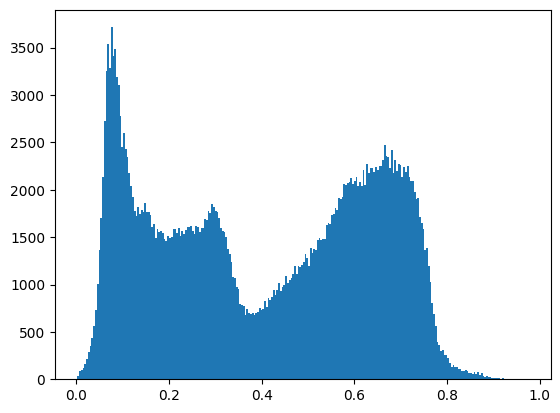

In [58]:
plt.hist(image_grayscale.ravel(),bins=256)
plt.show()

In [67]:
threshold = 0.4
segmented_image = image_grayscale > threshold
segmented_image

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(700, 471))

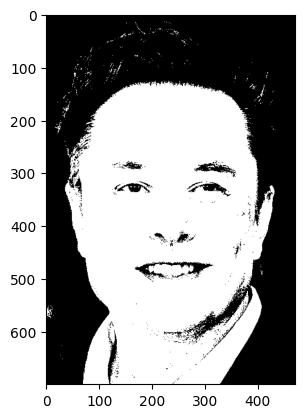

In [68]:
plt.imshow(segmented_image,cmap='gray')

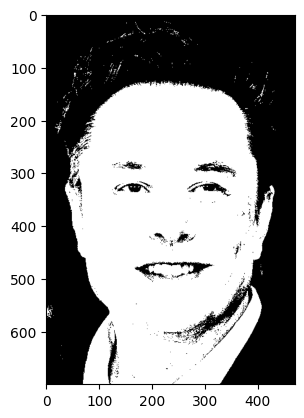

In [71]:
thresh = threshold_otsu(image_grayscale)
segmented_image_otsu = image_grayscale > thresh
plt.imshow(segmented_image_otsu,cmap='gray')

In [62]:
thresh

np.float64(0.39947353707107847)

Text(0.5, 1.0, 'Otsu')

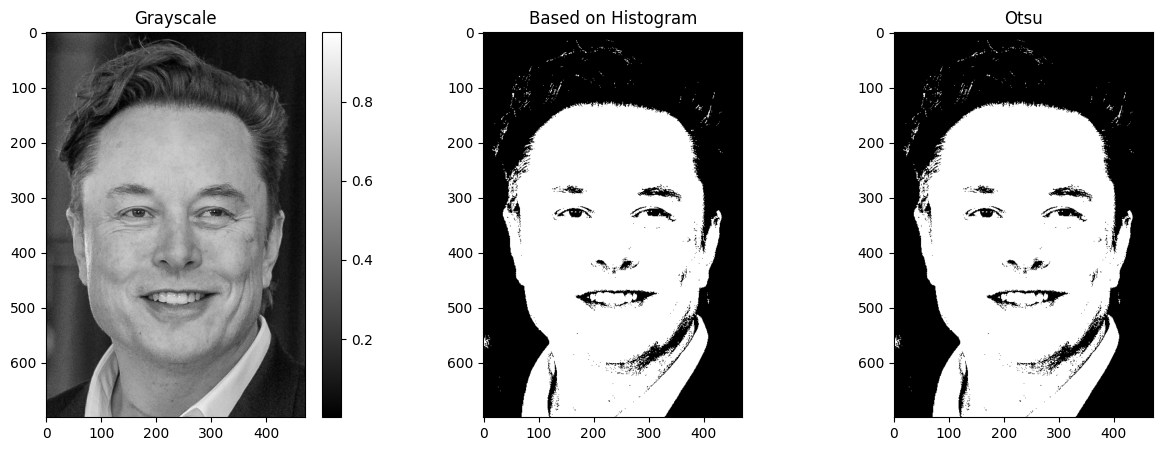

In [75]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
im = ax[0].imshow(image_grayscale,cmap='gray')
ax[0].set_title('Grayscale')
fig.colorbar(im,ax=ax[0])
ax[1].imshow(segmented_image,cmap='gray')
ax[1].set_title('Based on Histogram')
ax[2].imshow(segmented_image_otsu,cmap='gray')
ax[2].set_title('Otsu')

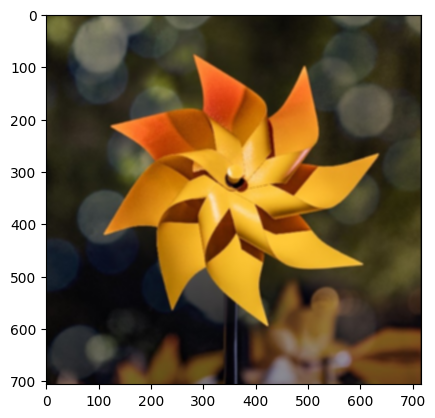

In [119]:
elon = imread('edgeflower.jpg')
elon = cv2.blur(elon,(5,5))
plt.imshow(elon)

In [120]:
grayscale = np.array([[255],[157],[0]]) # Grayscale
print("Grayscale Dimension : ",grayscale.ndim)

colorscale = np.array([[[255,255,255]],[[0,0,0]],[[125,241,255]]]) # Grayscale
print("Colorscale Dimension : ",colorscale.ndim)

Grayscale Dimension :  2
Colorscale Dimension :  3


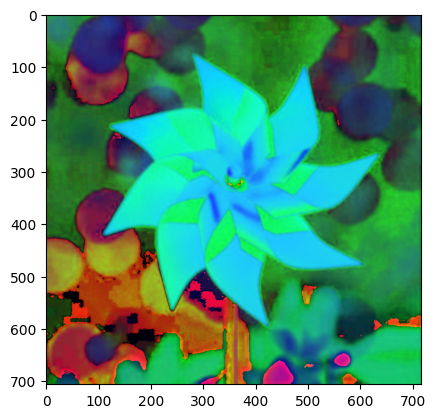

In [121]:
elon_hsv = rgb2hsv(elon)
plt.imshow(elon_hsv,cmap='hsv')

Text(0.5, 1.0, 'Brightness')

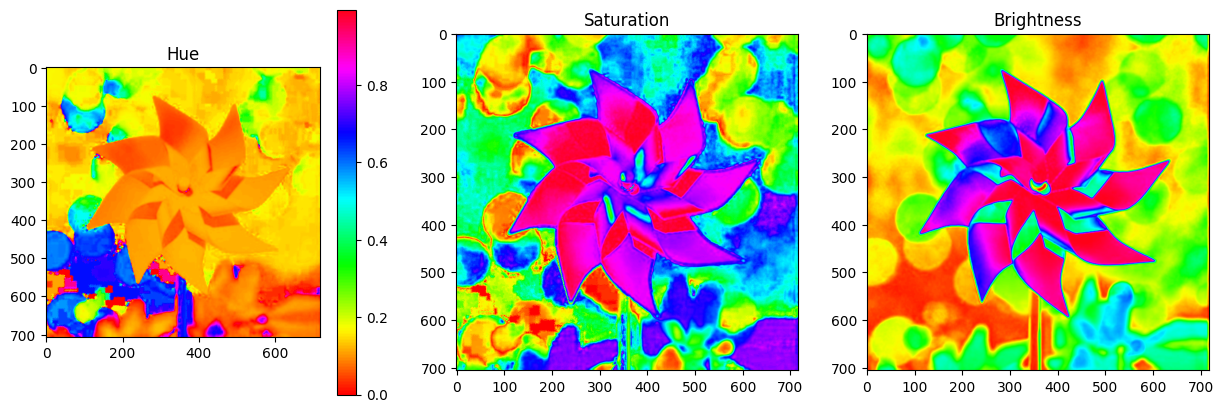

In [122]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
im = ax[0].imshow(elon_hsv[:,:,0],cmap='hsv')
ax[0].set_title('Hue')
fig.colorbar(im,ax=ax[0])
ax[1].imshow(elon_hsv[:,:,1],cmap='hsv')
ax[1].set_title('Saturation')
ax[2].imshow(elon_hsv[:,:,2],cmap='hsv')
ax[2].set_title('Brightness')

In [123]:
lowermask = elon_hsv[:,:,0] > 0.001
lowermask

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(706, 717))

In [124]:
uppermask = elon_hsv[:,:,0] < 0.1
uppermask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True]], shape=(706, 717))

In [125]:
mask = lowermask* uppermask

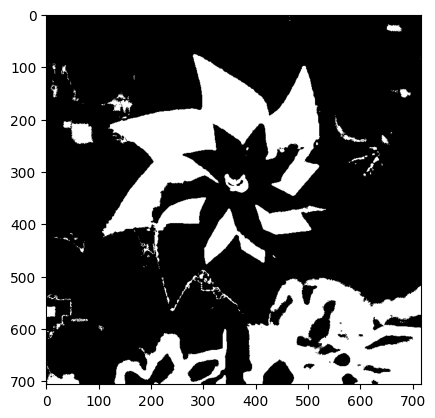

In [126]:
plt.imshow(mask,cmap='gray')

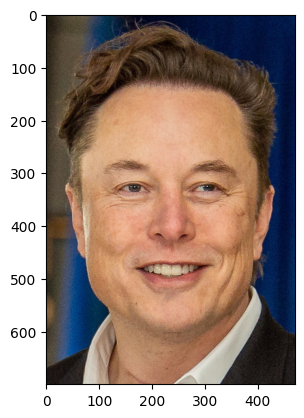

In [106]:
elon = plt.imread('elon.jpg')
red = elon[:,:,0]*mask
green = elon[:,:,1]*mask
blue = elon[:,:,2]*mask
all_channels = np.dstack((red,green,blue))
plt.imshow(elon)

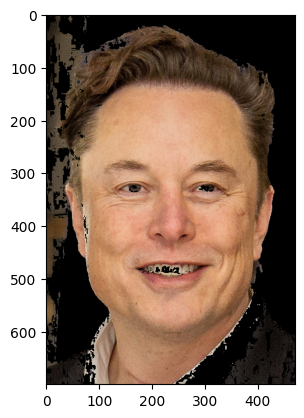

In [107]:
plt.imshow(all_channels)